In [1]:
# ======================================
# RNN 실습
# 목표 :
# - 순차 데이터 분류
# - RNN(LSTM) 모델 학습
# - 학습 결과 저장
# - 저장된 모델결과 불러오기
# - 신규 시퀀스 예측
# - 학습 결과 및 예측결과 시각화
# ======================================

기존 새로운 sequence 데이터 넣었을 때 sin, cos, 증가 형태인지 확인
- class1 : 사인 형태 시퀀스
- class2 : 코사인 형태 시퀀스
- class3 : 증가 시퀀스

In [2]:
import  numpy as np
import  pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from day7 import history

# 시드 고정
np.random.seed(42)
tf.random.set_seed(42)


import seaborn as sns
from keras.src.utils import to_categorical
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
# ======================================
# 1. 데이터 가져오기
# ======================================

# 샘플 수 정의
n_sample = 1500

# 시퀀스 길이
seq_len =50

# 클래스 수 정의
n_classes = 3

# 빈 리스트 생성
X = []
y = []

# 클래스 별 시퀀스 생성
for i in range(n_sample):
    # 시간축 생성
    t = np.linspace(0,2*np.pi, seq_len)

    # 클래스를 랜덤하게 선택
    label = np.random.randint(0,3)

    # 클래스 0이면 Sine 패턴을 생성
    if label == 0:
        seq = np.sin(t) + np.random.normal(0,0.1,seq_len)

    #클래스 1이면 cosine 패턴을 생성
    elif label == 1:
        seq = np.cos(t) + np.random.normal(0,0.1,seq_len)

    # 클래스 2 이면 증가 추세 패턴을 생성
    else:
        seq = np.linspace(-1,1,seq_len) + np.random.normal(0,0.1,seq_len)

    # 시퀀스 데이터 추가
    X.append(seq)
    # 라벨도 추가
    y.append(label)

# 학습할 때는 리스트 형태로는 학습 못하니까 array 형태로 변환
X = np.array(X)
y = np.array(y)


# RNN 입력 형태인 (샘플 수, 시퀀스 길이, 특성 수) 로 reshape 필요
X = X.reshape(-1, seq_len, 1)


In [5]:
y


array([2, 0, 0, ..., 2, 0, 0], shape=(1500,))

In [6]:
# ======================================
# 2. 데이터 분리
# ======================================

X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size = 0.2, random_state = 42,stratify = y
)

In [7]:
# ======================================
# 3. 모델 정의
# ======================================

model = Sequential()

# 첫 번째 LSTM 층을 추가
model.add(LSTM(64, input_shape=(seq_len, 1), return_sequences =False))

# 드롭아웃 ㅊ푸가
model.add(Dropout(0.2))

# 출력 위한 완전 연결층 추가 (Flatten 한 데이터 써야 하니까 덴스 레이어 추가
model.add(Dense(32,activation='relu'))

# 출력층 추가
model.add(Dense(n_classes, activation='softmax')) #아까 세개로 지정함. 클래스 출력층은 클래스 개수로 지정.

D:\anaconda3\envs\analyzer\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
# ======================================
# 4. 모델 컴파일 정의
# ======================================

model.compile(
    optimizer='adam', #아담이 학습 최적화에 성능이 제일 좋다.
    loss='sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

# 학습 조기 종료 설정 (validation loss 가 더이상 개선되지 않으면 조기 종료)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
)

In [11]:
# ======================================
# 5. 모델 학습
# ======================================

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.7521 - loss: 0.7319 - val_accuracy: 1.0000 - val_loss: 0.2010
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0494 - val_accuracy: 1.0000 - val_loss: 0.0059
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0041 - val_accuracy: 1.0000 - val_loss: 0.0018
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 1.0000 - val_loss: 7.4365e-04
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 9.9151e-04 - val_accuracy: 1.0000 - val_loss: 5.3925e-04
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 7.1725e-04 - val_accuracy: 1.0000 - val_loss: 4.1499e-04
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 5.8991e-04 - 

In [13]:
# ======================================
# 6. 성능 평가
# ======================================

test_loss, test_acc = model.evaluate( X_test, y_test ,verbose=0)

# 결과 출력
print("테스트 손실 : ", test_loss)
print("테스트 정확도 : ", test_acc)

테스트 손실 :  2.6676640118239447e-05
테스트 정확도 :  1.0


In [14]:
# ======================================
# 7. 예측 / 확률 계산
# ======================================

# 예측 확률 계산
y_prob = model.predict(X_test)

# 최종 예측 클래스 계산
y_pred = np.argmax(y_prob, axis =1)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [16]:
# ======================================
# 8. 학습 결과 저장
# ======================================
model.save('.data/results/RNN_LSTM_Model.h5')

# 읽어오기
loaded_model = tf.keras.models.load_model('.data/results/RNN_LSTM_Model.h5')

In [17]:
# ======================================
# 9. 신규 데이터 예측
# ======================================


# 신규 5개 패턴을 사용
new_seq = X_test[:5]

# 신규 시퀀스를 예측
new_prob = loaded_model.predict(new_seq)

# 최종 클래스를 예측
new_pred = np.argmax(new_prob, axis =1)

# 예측 결과 출력
for i in range(len(new_seq)):
    print(f"{i}번 시퀀스 - 예측 클래스 : {new_pred[i]}, 확률 분포 : {new_prob[i]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
0번 시퀀스 - 예측 클래스 : 2, 확률 분포 : [1.3919595e-06 3.8337414e-05 9.9996018e-01]
1번 시퀀스 - 예측 클래스 : 2, 확률 분포 : [1.5016557e-06 3.9541952e-05 9.9995887e-01]
2번 시퀀스 - 예측 클래스 : 0, 확률 분포 : [9.9998069e-01 1.8356017e-05 9.4732610e-07]
3번 시퀀스 - 예측 클래스 : 0, 확률 분포 : [9.9998069e-01 1.8321649e-05 1.0096926e-06]
4번 시퀀스 - 예측 클래스 : 2, 확률 분포 : [1.3793111e-06 3.7971629e-05 9.9996054e-01]


In [18]:
# 0 ( 사인 형태)
# 1 ( 코사인 형태)
# 2 ( 증가 형태 )

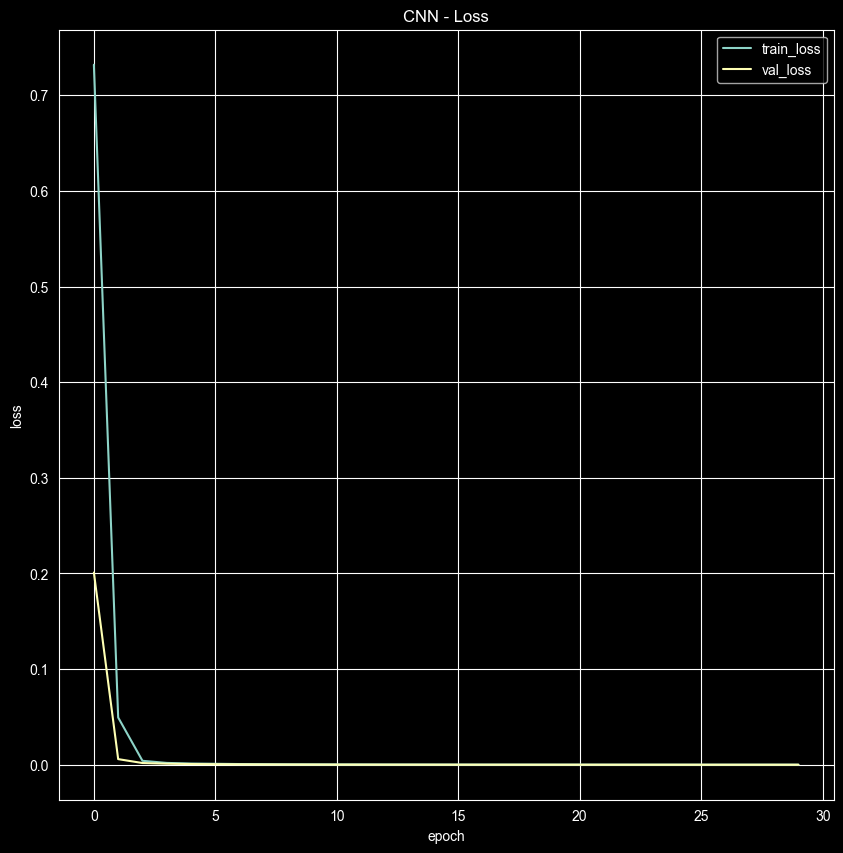

In [19]:
# ======================================
# 10. 결과 시각화
# ======================================
# 학습 손실 그래프
plt.figure(figsize=(10,10))
plt.plot(history.history['loss'],label = 'train_loss' )
plt.plot(history.history['val_loss'],label = 'val_loss')
plt.title('RNN - Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)
plt.show()

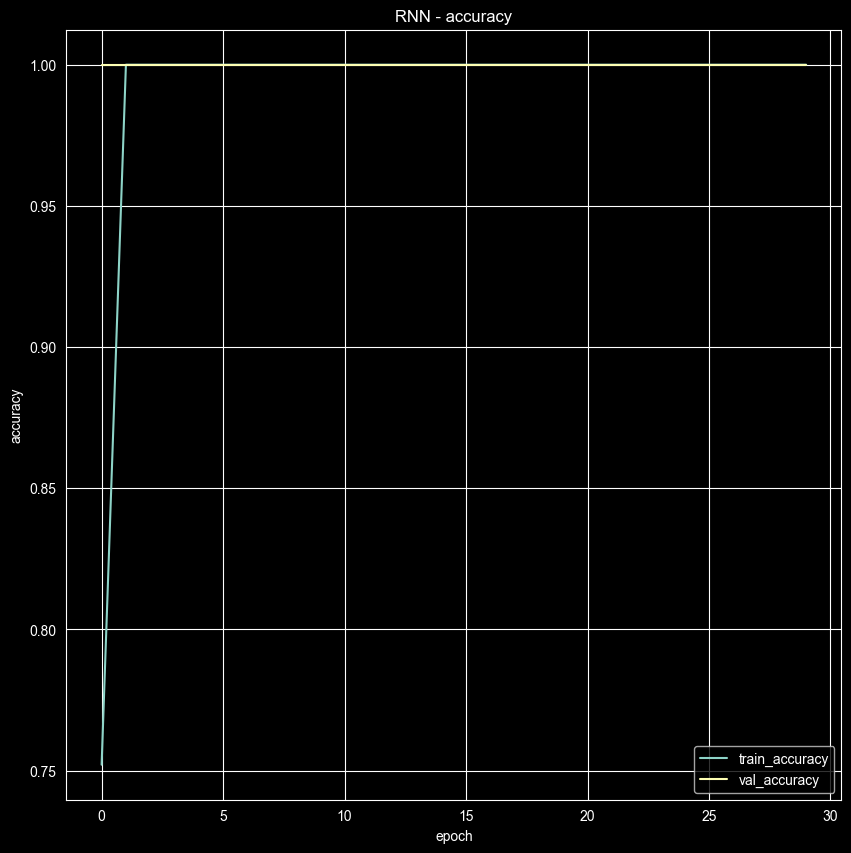

In [21]:
# 학습 정확도 그래프
plt.figure(figsize=(10,10))
plt.plot(history.history['accuracy'],label = 'train_accuracy' )
plt.plot(history.history['val_accuracy'],label = 'val_accuracy')
plt.title('RNN - accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.grid(True)
plt.show()

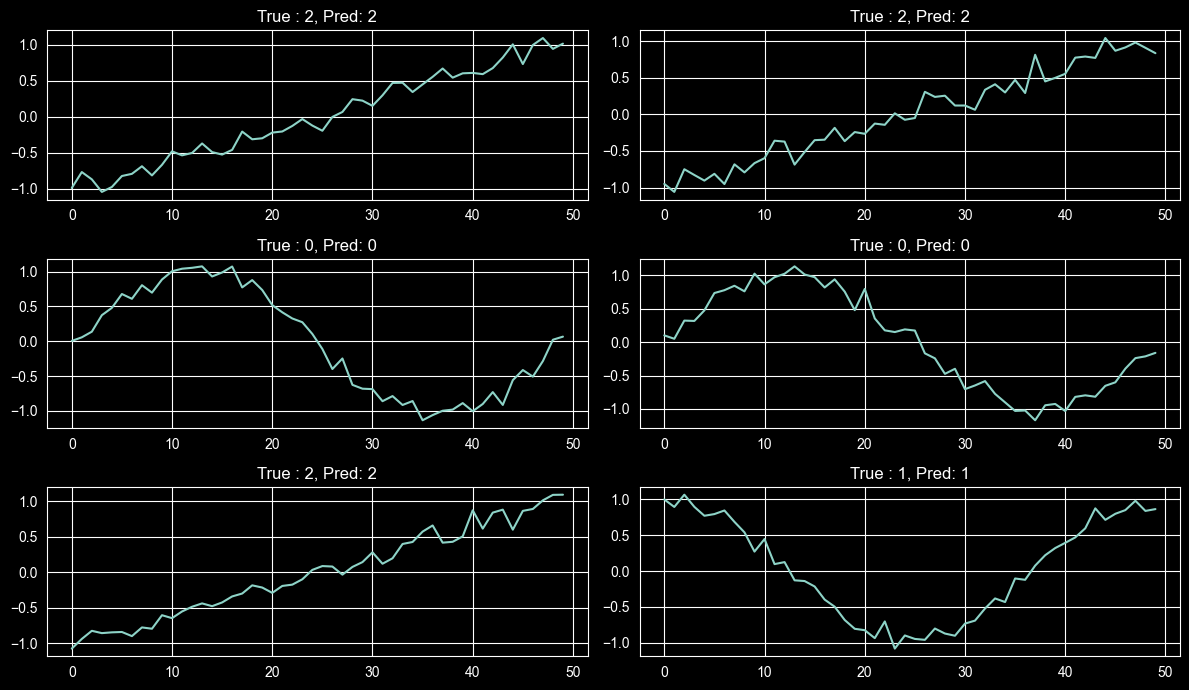

In [22]:
# 시퀀스 패턴과 예측 결과 시각화
plt.figure(figsize=(12,7))
for i in range(6):
    plt.subplot(3,2,i+1)
    plt.plot(X_test[i].flatten())
    plt.title(f"True : {y_test[i]}, Pred: {y_pred[i]}")
    plt.grid(True)

plt.tight_layout()
plt.show()

In [23]:
# 문제는 잘 가다가 이상 패턴이 발생함.
# 문장도 시퀀스로 들어오는 거니까. 다음 단어도 예측 가능함. 텍스트 분석에서도 많이 쓴다.